## 📊 Dataset Exploration (Google Landmarks Dataset)

In this section, we explored the **Google Landmarks Dataset (GLDv2)**, which contains millions of images of landmarks from around the world. Each image is labeled with:

- **`id`** → Unique identifier for the image  
- **`landmark_id`** → Numerical ID assigned to the landmark  
- **`category`** → Human-readable class/category describing the landmark type  
- **`image`** → The actual image data  
- **`label`** → The landmark label mapped from `landmark_id`  

---

### ✅ Steps Performed
1. **Loaded the Dataset**  
   - Imported the dataset containing metadata for landmark images.  
   - Verified dataset structure and checked the first few rows.  

2. **Merged Landmark Names (if available)**  
   - Combined the training metadata with the `landmarks.csv` file to map `landmark_id` → landmark name.  
   - This allows us to work with *human-readable names* instead of just numerical IDs.  

3. **Visualized Samples**  
   - Displayed random sample images with their `id`, `landmark_id`, `category`, and `label`.  
   - Verified that the dataset is correctly loaded and images are accessible.  

4. **Extracted Categories**  
   - Pulled out all unique values from the `category` column.  
   - Sorted them to see the distinct landmark types represented in the dataset.  

---

### 📂 Categories
We found that the dataset includes the following unique **categories**:

- A set of human-readable classes (such as *historical_building, museum, natural_site*, etc.).  
- These categories help us better understand the **semantic grouping** of the landmarks beyond just their IDs.  

This prepares us for the next stage: **EDA & Visualization**, where we will analyze the number of images per category and check dataset balance.


In [1]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from PIL import Image
from io import BytesIO

# For visualization
import seaborn as sns


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005-39f96bd6997c0a(…):   0%|          | 0.00/486M [00:00<?, ?B/s]

data/train-00001-of-00005-59e18329abb78a(…):   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00005-de76cb6cacc009(…):   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00003-of-00005-877102efad5548(…):   0%|          | 0.00/483M [00:00<?, ?B/s]

...

data/test-00000-of-00002-7cf5e61152ca176(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00001-of-00002-96358902e6d5b80(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36463 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9116 [00:00<?, ? examples/s]

Train sample size: (5000, 5)
Test sample size: (2000, 5)
Columns: ['id', 'landmark_id', 'category', 'image', 'label']

Number of classes (in sample): 51


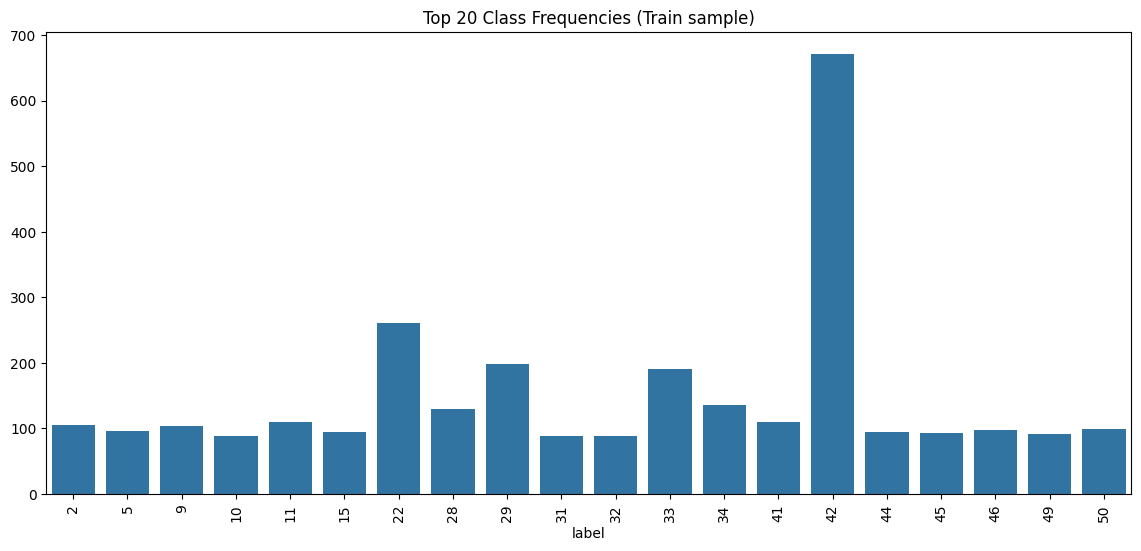

In [2]:
# !pip install -q datasets

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io

# ----------------------
# Load dataset (lazy)
# ----------------------
hf = load_dataset("pemujo/GLDv2_Top_51_Categories")

# Take only a sample for EDA
train_sample = hf["train"].shuffle(seed=42).select(range(5000))   # 5k rows
test_sample  = hf["test"].shuffle(seed=42).select(range(2000))    # 2k rows

# Convert sample to pandas
df_train = pd.DataFrame(train_sample)
df_test  = pd.DataFrame(test_sample)

# ----------------------
# Basic info
# ----------------------
print("Train sample size:", df_train.shape)
print("Test sample size:", df_test.shape)
print("Columns:", df_train.columns.tolist())

# Label distribution
label_counts = df_train['label'].value_counts()
print("\nNumber of classes (in sample):", df_train['label'].nunique())

plt.figure(figsize=(14,6))
sns.barplot(x=label_counts.index[:20], y=label_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Class Frequencies (Train sample)")
plt.show()


## save top5 now from google dataset

In [3]:
import os
from collections import Counter
from datasets import load_dataset
from tqdm import tqdm


# -------------------------
# 2. تحديد أعلى 5 كلاس
# -------------------------
labels = hf["train"]["label"]
top5_classes = [cls for cls, _ in Counter(labels).most_common(5)]
print("Top 5 classes:", top5_classes)

# عمل mapping من الكلاسات الأصلية للأرقام الجديدة 0..4
class_mapping = {old: new for new, old in enumerate(top5_classes)}
print("Mapping:", class_mapping)

# -------------------------
# 3. دالة لحفظ الصور
# -------------------------
def save_images(dataset, split="train", base_dir="gldv2_top5"):
    for row in tqdm(dataset):
        old_label = row['label']
        if old_label not in class_mapping:
            continue  # skip classes not in top 5

        new_label = class_mapping[old_label]
        img = row['image']  # PIL Image

        # فولدر الكلاس الجديد
        class_dir = os.path.join(base_dir, split, str(new_label))
        os.makedirs(class_dir, exist_ok=True)

        # اسم ملف فريد
        img_id = row['id']
        img_path = os.path.join(class_dir, f"{img_id}.jpg")

        # حفظ الصورة
        img.save(img_path)

# -------------------------
# 4. تنفيذ الحفظ
# -------------------------
save_images(hf['train'], split="train")
save_images(hf['test'], split="test")

print("✅ تم تجهيز الداتا (top5) مع إعادة ترقيم الكلاسات")


Top 5 classes: [42, 22, 29, 33, 28]
Mapping: {42: 0, 22: 1, 29: 2, 33: 3, 28: 4}


100%|██████████| 9116/9116 [00:21<00:00, 418.79it/s]

✅ تم تجهيز الداتا (top5) مع إعادة ترقيم الكلاسات


## download dataset for egypt

In [4]:

!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 58.2 MB/s eta 0:00:00


In [5]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="N79o2Kg5Jx1ItlvgpiNN")
project = rf.workspace("gp-j4r5m").project("augmented-iklfg")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to augmented-1 in yolov11:: 100%|██████████| 27764/27764 [00:11<00:00, 2479.06it/s]


In [6]:
import os
import glob
import collections
import shutil
from sklearn.model_selection import train_test_split

In [7]:
def get_top_classes(dataset_path, top_n=5):




    label_files = glob.glob(os.path.join(dataset_path,"**", "labels", "*.txt"), recursive=True)

    class_counts = collections.Counter()
    for lf in label_files:
        with open(lf, "r") as f:
            for line in f:
                if line.strip():
                    cid = int(line.split()[0])
                    class_counts[cid] += 1
    return [cid for cid, _ in class_counts.most_common(top_n)]

In [8]:
def collect_class_subset(dataset_path, selected_classes):
    all_images, all_labels = [], []



    label_files = glob.glob(os.path.join(dataset_path,"**", "labels", "*.txt"), recursive=True)


    for lf in label_files:
        with open(lf, "r") as f:
            lines = f.readlines()
            if not lines:
                continue
            cid = int(lines[0].split()[0])
            if cid in selected_classes:
                base = os.path.splitext(os.path.basename(lf))[0]


                img_candidates = glob.glob(os.path.join(dataset_path, "**", "images", base + ".*"), recursive=True)

                # img_candidates = glob.glob(os.path.join(dataset_path, "images", "**", base + ".*"), recursive=True)
                if img_candidates:
                    all_images.append(img_candidates[0])
                    all_labels.append(lf)
    return all_images, all_labels

In [9]:
def merge_datasets(egypt_path,output_path, top_n=5):
    # 1) احسب أعلى 20 من كل واحدة
    top20_egypt = get_top_classes(egypt_path, top_n=top_n)
    print("📌 Top 20 Egypt:", top20_egypt)

    # 2) جمع الصور والليبلز
    imgs_egypt, lbls_egypt = collect_class_subset(egypt_path, top20_egypt)

    all_images = imgs_egypt
    all_labels = lbls_egypt

    print(f"📊 Collected {len(all_images)} images total")

    # 3) Split train/test
    train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(
        all_images, all_labels, test_size=0.2, random_state=42,shuffle=True
    )

    # 4) أنشئ المجلدات
    for split in ["train", "test"]:
        os.makedirs(os.path.join(output_path, "images", split), exist_ok=True)
        os.makedirs(os.path.join(output_path, "labels", split), exist_ok=True)

    # 5) نسخ train
    for img, lbl in zip(train_imgs, train_lbls):
        shutil.copy(img, os.path.join(output_path, "images", "train", os.path.basename(img)))
        shutil.copy(lbl, os.path.join(output_path, "labels", "train", os.path.basename(lbl)))

    # 6) نسخ test
    for img, lbl in zip(test_imgs, test_lbls):
        shutil.copy(img, os.path.join(output_path, "images", "test", os.path.basename(img)))
        shutil.copy(lbl, os.path.join(output_path, "labels", "test", os.path.basename(lbl)))

    print(f"✅ Done! {len(train_imgs)} train + {len(test_imgs)} test saved in {output_path}")


In [10]:
# ---------- تنفيذ ----------
egypt_path = "/content/augmented-1"
output_path = "/content/Merged_Top20_YOLO"

merge_datasets(egypt_path, output_path, top_n=5)

📌 Top 20 Egypt: [19, 53, 24, 36, 5]
📊 Collected 3477 images total
✅ Done! 2781 train + 696 test saved in /content/Merged_Top20_YOLO


In [11]:
import os
import glob

# number of images and classes in Merged_Top20_YOLO Dataset

dataset_path = "/content/Merged_Top20_YOLO"

img_files = glob.glob(os.path.join(dataset_path, "images", "**", "*.jpg"), recursive=True)
img_files += glob.glob(os.path.join(dataset_path, "images", "**", "*.png"), recursive=True)
num_images = len(img_files)

class_ids = set()
label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

for lf in label_files:
    with open(lf, "r") as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_ids.add(cid)

num_classes = len(class_ids)

print(f"number of images {num_images}")
print(f"number of classes: {num_classes}")
# print(f"IDs: {sorted(class_ids)}")


number of images 3477
number of classes: 5


In [12]:
import os
import glob

# الكلاسات المختارة
# selected_classes = [19, 53, 24, 36, 5,126, 106, 113, 117, 112]

selected_classes = [5,19,24,36,53]


# اعمل mapping جديد (0 → n-1)
class_mapping = {old_id: new_id for new_id, old_id in enumerate(selected_classes)}

print("📌 Class Mapping:")
print(class_mapping)

# مسار الفولدر الجديد
dataset_path = "/content/Merged_Top20_YOLO"

# عدّل كل label files
label_files = glob.glob(os.path.join(dataset_path, "labels", "**", "*.txt"), recursive=True)

for lf in label_files:
    new_lines = []
    with open(lf, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            old_cid = int(parts[0])
            if old_cid in class_mapping:   # نعدّل لو الكلاس مختار
                parts[0] = str(class_mapping[old_cid])
                new_lines.append(" ".join(parts))
    # overwrite الملف
    with open(lf, "w") as f:
        f.write("\n".join(new_lines))

print("✅ Done! كل الكلاسات اتعملها re-index من 0 →", len(selected_classes)-1)


📌 Class Mapping:
{5: 0, 19: 1, 24: 2, 36: 3, 53: 4}
✅ Done! كل الكلاسات اتعملها re-index من 0 → 4


## upload Model

In [13]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.8 MB/s eta 0:00:00


In [14]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
model = YOLO('/content/best.pt')

In [17]:
result2 = model.predict(source='/content/Merged_Top20_YOLO/images/train/1_0-3-_jpg.rf.8752f5e14a64154e0a6d738a504b82fe.jpg',conf=0.25,device=[-1,-1],save=True)

Searching for 2 idle GPUs with free memory >= 20.0% and free utilization >= 0.0%...
Selected idle CUDA devices [0]

image 1/1 /content/Merged_Top20_YOLO/images/train/1_0-3-_jpg.rf.8752f5e14a64154e0a6d738a504b82fe.jpg: 640x640 2 Great Pyramids of Gizas, 9.0ms
Speed: 20.8ms preprocess, 9.0ms inference, 392.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


In [18]:
from IPython.display import Image

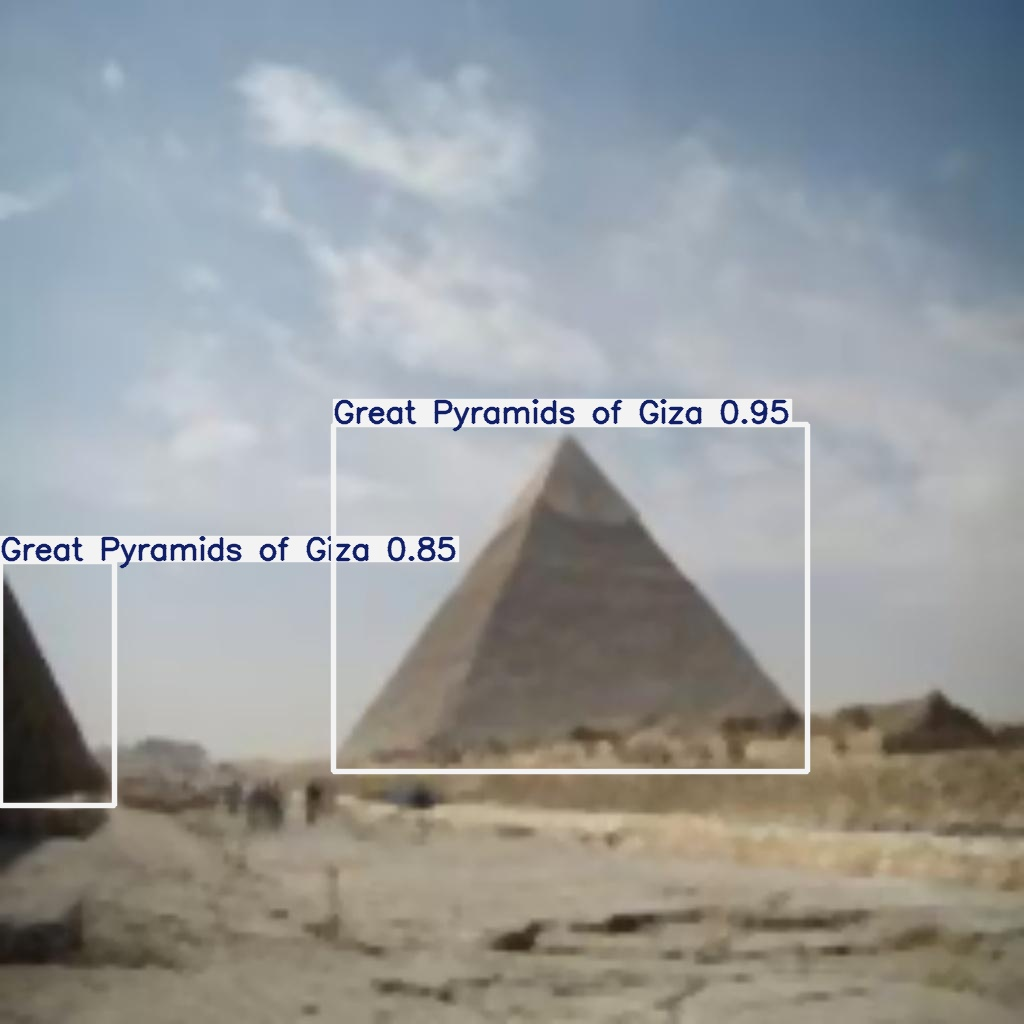

In [19]:
Image('/content/runs/detect/predict/1_0-3-_jpg.rf.8752f5e14a64154e0a6d738a504b82fe.jpg',width=600)

## Now top 5 from google store in gldv2_top5 folder

## and top 5 from egypt store in Mergerd_Top20_YOLO folder

## Now enter egypt to yolo model and store store cropped image

In [20]:
import os
from ultralytics import YOLO
from PIL import Image


def crop_and_save(model, images_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for img_name in os.listdir(images_dir):
        if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
            continue

        img_path = os.path.join(images_dir, img_name)

        # Run YOLO inference
        results = model(img_path)

        # افتح الصورة بالـ PIL
        img = Image.open(img_path).convert("RGB")

        # ------------------------
        # استخراج البوكسات وقص الصور
        # ------------------------
        for i, box in enumerate(results[0].boxes):
            cls_id = int(box.cls[0].item())   # class id
            x_min, y_min, x_max, y_max = box.xyxy[0].tolist()
            x_min, y_min, x_max, y_max = map(int, [x_min, y_min, x_max, y_max])

            # crop
            crop = img.crop((x_min, y_min, x_max, y_max))

            # فولدر الكلاس
            class_dir = os.path.join(output_dir, str(cls_id))
            os.makedirs(class_dir, exist_ok=True)

            # حفظ crop
            crop.save(os.path.join(class_dir, f"{img_name.replace('.jpg','')}_{i}.jpg"))

    print(f"✅ Cropping done for {images_dir} → saved to {output_dir}")



crop_and_save(model, "/content/Merged_Top20_YOLO/images/train", "egypt_cropped/train")
crop_and_save(model, "/content/Merged_Top20_YOLO/images/test", "egypt_cropped/test")


Streaming output truncated to the last 5000 lines.

image 1/1 /content/Merged_Top20_YOLO/images/train/2_275_jpg.rf.dd7e3f7188734d6f06b61cff129efd4d.jpg: 640x640 1 Sphinx of Amenmhat III, 12.1ms
Speed: 4.6ms preprocess, 12.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Merged_Top20_YOLO/images/train/4_26_jpg.rf.09da6fa38384792b8341d6f5c716889f.jpg: 640x640 1 Mask of Tutankhamun, 11.6ms
Speed: 4.9ms preprocess, 11.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Merged_Top20_YOLO/images/train/3_294_jpg.rf.8c6d1fd5d9bd3f9780986c28c4292f45.jpg: 640x640 1 Sphinx of Amenmhat III, 12.6ms
Speed: 5.0ms preprocess, 12.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Merged_Top20_YOLO/images/train/3_1-1-_jpg.rf.9a78a6837484a546d04ec29c5e751478.jpg: 640x640 1 Mask of Tutankhamun, 12.4ms
Speed: 4.9ms preprocess, 12.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 